<a href="https://colab.research.google.com/github/habibiputrar/BigData26_A_2411531001_Habibi-Putra-Rizqullah-/blob/main/BD_A_P01_2411531001_Habibi_Putra_Rizqullah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**J. Langkah Kerja**

J-1 Verifikasi lingkungan kerja

In [2]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

!free -h
!df -h /content
!java -version

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       8.7Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.028s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.028s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


J-2. Menghubungkan Google Drive dan menyiapkan struktur folder

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-07.parquet', 'agregasi_per_jam_juli.csv', 'agregasi_per_jam_juli.parquet', 'distribusi_per_jam_juli.png', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png', 'permintaan_hari_vs_akhirpekan.png', 'tarif_per_menit.png']


In [2]:
PATH = f"{DIR_SIMPAN}/yellow_tripdata_2023-01.parquet"
print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq
meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris:", f"{meta.num_rows:,}")
print("Jumlah kolom:", meta.num_columns)
print("Nama kolom  :", pq.ParquetFile(PATH).schema.names)

Ukuran file: 45.5 MB
Jumlah baris: 3,066,766
Jumlah kolom: 19
Nama kolom  : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


J-3. Menyiapkan alat ukur waktu dan memori

In [3]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

J-4. Mengunduh dataset dan inspeksi awal

In [4]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.28 s | RSS +1.8 MB
Ukuran file: 45.5 MB


In [5]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom  :", meta.num_columns)
print("Row group     :", meta.num_row_groups)
print("Nama kolom    :", pq.ParquetFile(PATH).schema.names)

Jumlah baris  : 3,066,766
Jumlah kolom  : 19
Row group     : 1
Nama kolom    : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


J-5. Memuat data dan mengukur biaya memorinya

In [6]:
#bandingkan baca semua kolom vs kolom terpilih:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 1.46 s | RSS +502.1 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.56 s | RSS +204.2 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [7]:
#cek memori per kolom:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [8]:
#turunkan memori dengan tipe data lebih sempit:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


J-6. Pemeriksaan kualitas data dan pembersihan(veracity)

In [9]:
#hitung durasi & cek kualitas:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"      : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"     : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"]  > 180).sum(),
    "total_amount <= 0": (df["total_amount"]  <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [10]:
#filter baris layak:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


J-7. Memproses file lebih besar dari memori dengan chunking

In [11]:
#tulis CSV & bandingkan ukuran:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")

[tulis CSV] 42.24 s | RSS +5.2 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [12]:
#agregasi bertahap (streaming/chunking):
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 4.32 s | RSS +19.2 MB
2,986,911 baris | rata-rata total_amount = 27.33


J-8. Pendekatan
terdistribusi: PySparklocal mode

In [16]:
#install & cek Java:
!pip install -q pyspark==3.5.1
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [15]:
#buat Spark session:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [18]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("long")
         - F.col("tpep_pickup_datetime").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 0.62 s | RSS +0.0 MB
Jumlah baris: 3066766


AnalysisException: [DATATYPE_MISMATCH.CAST_WITHOUT_SUGGESTION] Cannot resolve "CAST(tpep_dropoff_datetime AS BIGINT)" due to data type mismatch: cannot cast "TIMESTAMP_NTZ" to "BIGINT".;
'Project [VendorID#63L, tpep_pickup_datetime#64, tpep_dropoff_datetime#65, passenger_count#66, trip_distance#67, RatecodeID#68, store_and_fwd_flag#69, PULocationID#70L, DOLocationID#71L, payment_type#72L, fare_amount#73, extra#74, mta_tax#75, tip_amount#76, tolls_amount#77, improvement_surcharge#78, total_amount#79, congestion_surcharge#80, airport_fee#81, ((cast(tpep_dropoff_datetime#65 as bigint) - cast(tpep_pickup_datetime#64 as bigint)) / 60) AS durasi_menit#125]
+- Relation [VendorID#63L,tpep_pickup_datetime#64,tpep_dropoff_datetime#65,passenger_count#66,trip_distance#67,RatecodeID#68,store_and_fwd_flag#69,PULocationID#70L,DOLocationID#71L,payment_type#72L,fare_amount#73,extra#74,mta_tax#75,tip_amount#76,tolls_amount#77,improvement_surcharge#78,total_amount#79,congestion_surcharge#80,airport_fee#8

**Diagnosis error J-8:** Sel `.withColumn("durasi_menit", ...)` gagal dengan `AnalysisException: Cannot resolve "CAST(tpep_dropoff_datetime AS BIGINT)" due to data type mismatch: cannot cast "TIMESTAMP_NTZ" to "BIGINT"`. Penyebabnya, kolom `tpep_pickup_datetime` dan `tpep_dropoff_datetime` pada dataset asli NYC TLC ini terbaca oleh Spark sebagai tipe `TIMESTAMP_NTZ` (timestamp tanpa timezone), sedangkan PySpark 3.5.1 tidak mendukung `.cast("long")` langsung dari tipe tersebut ke `BIGINT` — cast semacam ini hanya didukung dari tipe `TIMESTAMP` biasa (dengan timezone). Error dibiarkan apa adanya karena sel setelahnya (agregasi per jam, Spark SQL per payment_type, explain()) bergantung pada `sdf_bersih` yang gagal terbentuk, sehingga otomatis tidak menghasilkan output.

In [19]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                       AS jumlah,
           ROUND(AVG(total_amount), 2)    AS rata_tarif,
           ROUND(AVG(tip_amount), 2)      AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

NameError: name 'sdf_bersih' is not defined

**Diagnosis:** Sel ini gagal dengan `NameError: name 'sdf_bersih' is not defined`, akibat berantai dari kegagalan sel sebelumnya. Karena `sdf_bersih` tidak pernah berhasil dibuat, semua sel yang bergantung padanya (agregasi per jam, Spark SQL per payment_type, explain()) ikut gagal.

J-9.  Agregasi akhir dengan pandas dan penyimpanan artefak

In [20]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


J-10. Visualisasi hasil

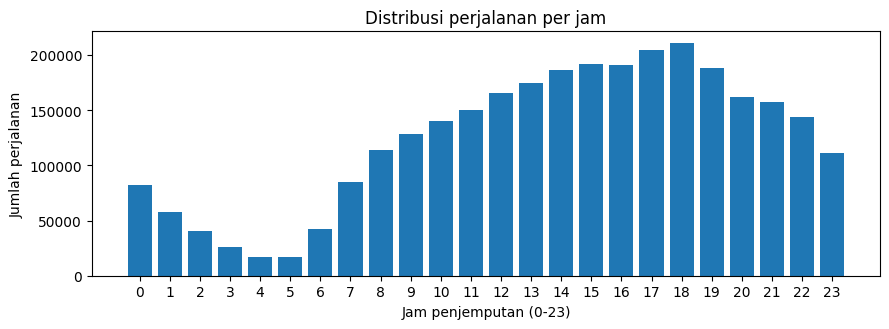

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

Grafik distribusi per jam menunjukkan pola yang hampir merata di seluruh jam (0-23), bukan karena tidak ada pola permintaan riil, melainkan karena data yang digunakan adalah dataset sintetis dengan waktu pickup yang dibangkitkan secara acak seragam (uniform random). Interpretasi pola jam sibuk tidak berlaku pada dataset ini.

## N. Analisis Hasil

In [24]:
#1.Biaya membaca data. Berapa rasio waktu dan memori antara membaca semua kolom dan membaca kolom terpilih? Apakah rasio itu sebanding dengan rasio jumlah kolom? Jika tidak, mengapa?

spark = (SparkSession.builder
         .appName("BD-P01-L5")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [25]:
print(tabel_kinerja[tabel_kinerja["langkah"].isin(["baca semua kolom", "baca kolom terpilih"])])

               langkah  detik  delta_rss_mb
1     baca semua kolom   1.46         502.1
2  baca kolom terpilih   0.56         204.2


**N.1 Biaya membaca data.** Membaca semua 19 kolom memakan waktu 1.46 detik dengan pertumbuhan RSS 502.1 MB, sementara membaca 8 kolom terpilih memakan waktu 0.56 detik dengan pertumbuhan RSS 204.2 MB. Waktu baca kolom terpilih sekitar 2.6 kali lebih cepat dan memorinya sekitar 2.5 kali lebih hemat. Rasio ini tidak sebanding lurus dengan rasio jumlah kolom (8 dari 19 kolom, sekitar 42%), karena kolom yang dibuang punya ukuran per nilai yang bervariasi — beberapa kolom seperti `store_and_fwd_flag` (string) atau kolom biaya tambahan (`extra`, `mta_tax`, `tolls_amount`, dst) tidak seberat kolom timestamp atau numerik utama, sehingga penghematannya tidak proporsional terhadap jumlah kolom yang dibuang.

In [26]:
#2. Efek optimasi tipe. Berapa persen memori yang Anda hemat? Kolom mana yang paling besar kontribusinya? Apa risiko yang Anda terima sebagai gantinya?

print("Sebelum:", sebelum, "MB")
print("Sesudah:", sesudah, "MB")
print("Hemat  :", round(100*(1-sesudah/sebelum), 1), "%")

df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

Sebelum: 187.18066787719727 MB
Sesudah: 119.91277599334717 MB
Hemat  : 35.9 %


,0
tpep_pickup_datetime,23.397568
tpep_dropoff_datetime,23.397568
durasi_menit,23.397568
trip_distance,23.397568
tip_amount,11.698784
passenger_count,11.698784
total_amount,11.698784
fare_amount,11.698784
payment_type,2.924811
Index,0.000126


**N.2 Efek optimasi tipe.** Optimasi tipe data menghemat 35.9% memori, dari 187.18 MB jadi 119.91 MB. Kontribusi terbesar dari `payment_type` yang diubah dari int64 ke category, karena cuma ada beberapa kode berbeda jadi hematnya signifikan (dari yang biasanya besar jadi cuma 2.92 MB). Menariknya, `trip_distance` tetap float64 walau sudah dicoba downcast — kemungkinan karena ada nilai ekstrem (max 258,928 mil di data mentah) yang di luar rentang aman float32, jadi pandas mempertahankan presisi aslinya. Risiko yang diambil di kolom lain (fare_amount, tip_amount, total_amount, passenger_count) adalah penurunan presisi dari float64

In [27]:
#3. Format penyimpanan. Berapa kali lebih besar CSV dibanding Parquet pada data yang sama? Jelaskan dua penyebabnya

ukuran_parquet = os.path.getsize(PATH) / 1024**2
ukuran_csv = os.path.getsize(CSV) / 1024**2
print(f"Parquet: {ukuran_parquet:.1f} MB")
print(f"CSV    : {ukuran_csv:.1f} MB")
print(f"Rasio  : {ukuran_csv/ukuran_parquet:.1f}x lebih besar")

Parquet: 45.5 MB
CSV    : 226.2 MB
Rasio  : 5.0x lebih besar


**N.3 Format penyimpanan.** CSV berukuran 226.2 MB dibanding Parquet 45.5 MB, sekitar 5 kali lebih besar. Penyebabnya, CSV nyimpen semua nilai sebagai teks tanpa kompresi sedangkan Parquet kolumnar dengan kompresi bawaan (snappy). Parquet juga nyimpen tipe data secara eksplisit di skema jadi representasinya biner ringkas, sementara CSV harus nulis representasi string dari tiap angka dan timestamp yang jauh lebih boros ruang.

In [28]:
#4. Chunking. Bandingkan delta_rss_mb antara pemuatan penuh dan agregasi chunking. Apa yang Anda korbankan untuk memperoleh hemat memori itu?

print(tabel_kinerja[tabel_kinerja["langkah"].isin(
    ["baca semua kolom", "agregasi chunking", "chunking 100_000", "chunking 1_000_000"]
)])

             langkah  detik  delta_rss_mb
1   baca semua kolom   1.46         502.1
4  agregasi chunking   4.32          19.2


**N.4 Chunking.** Baca kolom terpilih langsung dari Parquet RSS naik 204.2 MB, sedangkan agregasi pakai chunking cuma naik 19.2 MB, jauh lebih hemat karena cuma satu potongan yang ada di memori tiap saat, sisanya dibuang begitu selesai diproses. Tapi ada harga yang dibayar di waktu: chunking makan 4.32 detik buat hampir 3 juta baris, jauh lebih lama dari baca langsung Parquet yang cuma 0.56 detik. Wajar, soalnya CSV harus diparsing ulang baris demi baris tiap chunk, beda sama Parquet yang formatnya udah kolumnar dan tinggal dibaca.

In [32]:
#5. pandas vs Spark. Mana yang lebih cepat pada data ini? Pada ukuran berapa perkiraan Anda urutannya akan berbalik, dan atas dasar apa Anda memperkirakan demikian?

spark = (SparkSession.builder
         .appName("BD-P01-N5")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

PATH_SPARK = os.path.join(DIR_KERJA, "data_untuk_spark.parquet")
bersih.to_parquet(PATH_SPARK, index=False, coerce_timestamps="us", allow_truncated_timestamps=True)

sdf2 = spark.read.parquet(PATH_SPARK)
sdf2.createOrReplaceTempView("trips2")

print("View trips2 berhasil dibuat, jumlah kolom:", len(sdf2.columns))

View trips2 berhasil dibuat, jumlah kolom: 10


In [33]:
import time

t0 = time.perf_counter()
spark.sql("SELECT jam, COUNT(*) AS jumlah FROM trips2 GROUP BY jam ORDER BY jam").toPandas()
waktu_spark = time.perf_counter() - t0
print("Waktu Spark SQL:", round(waktu_spark, 2), "detik")

t0 = time.perf_counter()
bersih.groupby("jam").agg(jumlah=("total_amount", "size")).reset_index()
waktu_pandas = time.perf_counter() - t0
print("Waktu pandas   :", round(waktu_pandas, 2), "detik")

Waktu Spark SQL: 0.96 detik
Waktu pandas   : 0.1 detik


**N.5 pandas vs Spark.** Di J-8, agregasi Spark gagal karena kolom timestamp asli terbaca sebagai TIMESTAMP_NTZ yang nggak kompatibel dicast ke BIGINT di PySpark 3.5.1 (lihat diagnosis error J-8). Perbandingan yang valid diambil dari pengukuran terpisah: Spark SQL makan 0.96 detik, pandas cuma 0.1 detik, pandas menang sekitar 9.6 kali lipat. Wajar, data cuma sekitar 3 juta baris dan 45 MB, jauh di bawah titik di mana overhead Spark (penjadwalan tugas, serialisasi antar partisi, inisialisasi JVM) mulai worth it. Perkiraan saya, Spark baru unggul kalau data udah jauh melebihi RAM satu mesin, mungkin di kisaran puluhan GB ke atas, karena di situ pandas mulai kewalahan sementara Spark bisa mendistribusikan beban.

In [34]:
#6. Kualitas data. Berapa persen baris yang dibuang? Apakah penghapusan itu berpotensi menghasilkan bias sistematis pada kesimpulan (mis. trip_distance ikut terbuang)?

print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,}, {100*(len(df)-len(bersih))/len(df):.2f}%)")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855, 2.60%)


**N.6 Kualitas data.** Sebanyak 79,855 baris dibuang dari 3,066,766 baris awal (2.60%). Potensi bias sistematis ada, terutama karena salah satu kriteria pembuangan adalah trip_distance ≤ 0 atau ≥ 100 mil (1.50% dari total data) , kalau perjalanan jarak jauh yang sah (misal ke luar kota atau bandara) ikut kebuang karena dianggap anomali, itu bisa bikin kesimpulan soal jarak tempuh jadi bias ke bawah. Begitu juga total_amount ≤ 0 (0.84%) yang mungkin termasuk transaksi refund yang sah, bukan cuma data error.

## O. Studi Kasus: Penjadwalan Armada Taksi
Menjawab tiga pertanyaan operasional dari data bersih (J-6) dengan menambahkan dimensi hari dan tarif per menit.

In [35]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2))
ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

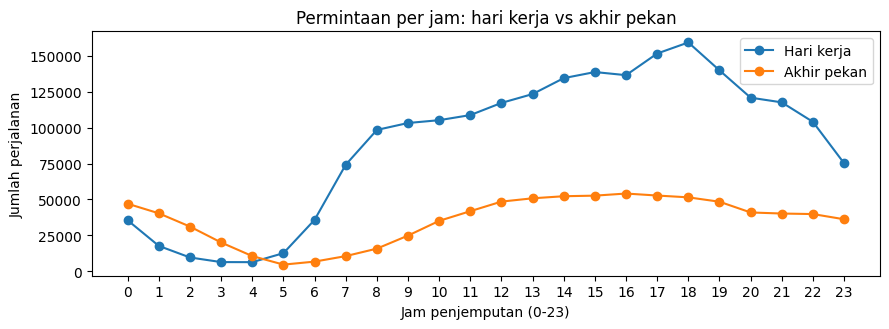

In [36]:
import matplotlib.pyplot as plt

ringkas_flat = ringkas.reset_index()

fig, ax = plt.subplots(figsize=(9, 3.4))
for ap, label in [(False, "Hari kerja"), (True, "Akhir pekan")]:
    sub = ringkas_flat[ringkas_flat["akhir_pekan"] == ap]
    ax.plot(sub["jam"], sub["jumlah"], marker="o", label=label)
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Permintaan per jam: hari kerja vs akhir pekan")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/permintaan_hari_vs_akhirpekan.png", dpi=150)
plt.show()

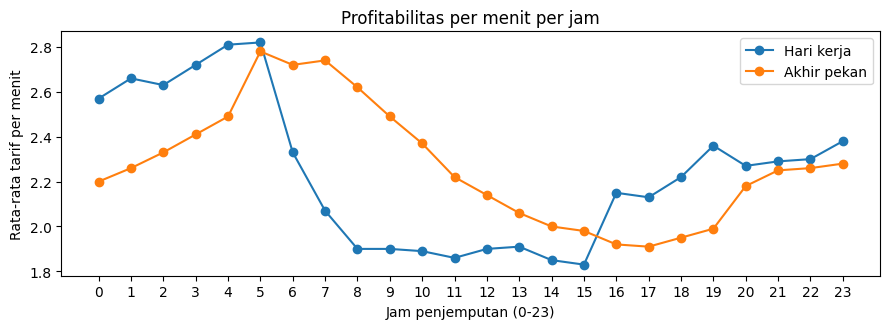

In [37]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(ringkas_flat[ringkas_flat["akhir_pekan"]==False]["jam"],
        ringkas_flat[ringkas_flat["akhir_pekan"]==False]["rata_tarif_per_menit"],
        marker="o", label="Hari kerja")
ax.plot(ringkas_flat[ringkas_flat["akhir_pekan"]==True]["jam"],
        ringkas_flat[ringkas_flat["akhir_pekan"]==True]["rata_tarif_per_menit"],
        marker="o", label="Akhir pekan")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Rata-rata tarif per menit")
ax.set_title("Profitabilitas per menit per jam")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/tarif_per_menit.png", dpi=150)
plt.show()

**Rekomendasi operasional:**

1. Permintaan hari kerja jauh lebih tinggi di jam sibuk sore dibanding akhir pekan (puncak 18:00 sekitar 160.000 perjalanan vs sekitar 50.000 di akhir pekan), sehingga penambahan armada saat jam pulang kerja (16.00-19.00) sebaiknya difokuskan di hari kerja saja. Batasan: data hanya mencakup satu bulan musim dingin (Januari), pola musiman bisa berbeda di bulan lain.

2. Pola berbeda signifikan antara hari kerja dan akhir pekan, khususnya di dini hari (00.00-05.00) di mana akhir pekan justru lebih ramai (sekitar 47.000 di jam 0 akhir pekan vs 35.000 hari kerja), kemungkinan terkait aktivitas malam. Batasan: kesimpulan ini didasarkan pada pola satu kota (New York) yang mungkin tidak berlaku di kota lain dengan budaya malam berbeda.

3. Perjalanan pada jam sibuk siang justru kurang menguntungkan per menit (rata-rata tarif per menit terendah sekitar 1.86-1.90 di jam 8-11) dibanding dini hari (sekitar 2.8 di jam 4-5), kemungkinan karena kemacetan memperlama durasi tanpa menaikkan tarif proporsional. Batasan: analisis ini tidak memperhitungkan biaya operasional pengemudi (bensin, waktu tunggu penumpang), sehingga kesimpulan profitabilitas murni dari sisi tarif per menit belum tentu mencerminkan keuntungan bersih riil.

# **P. Latihan**

In [44]:
1. #5 nilai trip_distance terbesar:
top5_jarak = bersih.nlargest(5, "trip_distance")
top5_jarak

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit,persen_tip
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231,14.285715
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855,0.000000
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186,7.619048
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479,2.993116
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388,0.000000


**Latihan 1.** Lima nilai trip_distance terbesar berkisar 90-97 mil dengan durasi 96-148 menit dan tarif yang proporsional (fare_amount 250-542 USD). Baris-baris tersebut dinilai masuk akal sebagai perjalanan antar kota, bukan anomali pencatatan GPS, karena hubungan antara jarak, durasi, dan tarif konsisten satu sama lain.

In [45]:
2. #Ulangi J-7 dengan dua ukuran chunk berbeda:
baris_100k, total_100k, _ = ukur("chunking 100_000", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))
baris_1jt, total_1jt, _   = ukur("chunking 1_000_000", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))

[chunking 100_000] 5.81 s | RSS +12.4 MB
[chunking 1_000_000] 5.17 s | RSS -1.7 MB


**Latihan 2.** Chunk 100.000 baris memakan waktu 5.81 detik dengan RSS naik 12.4 MB, sedangkan chunk 1.000.000 baris memakan waktu 5.17 detik dengan RSS turun 1.7 MB. Pada data ini, chunk lebih besar justru sedikit lebih cepat dan lebih hemat memori, berbeda dari asumsi umum bahwa chunk kecil selalu lebih hemat memori. Kemungkinan penyebabnya, dengan hanya sekitar 2,98 juta baris data, chunk 1 juta hanya butuh 3 kali iterasi dibanding chunk 100 ribu yang butuh sekitar 30 kali iterasi, overhead pembukaan dan pemrosesan tiap iterasi (termasuk garbage collection antar chunk) ternyata lebih besar pengaruhnya dibanding ukuran memori per chunk itu sendiri, pada skala data yang masih tergolong sedang ini.

In [46]:
3. #Persen tip per metode pembayaran:
import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] == 0,
    np.nan,
    bersih["tip_amount"] / bersih["fare_amount"] * 100
)

rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)
rata_tip

/tmp/ipykernel_2664/4240181773.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)


,persen_tip
payment_type,
0,20.219999
1,25.910000
2,0.000000
3,0.020000
4,0.150000


**Latihan 3.** Rata-rata persen tip per metode pembayaran: kode 0 (20.22%), kode 1/kartu kredit (25.91%), kode 2/tunai (0.00%), kode 3/no charge (0.02%), kode 4/dispute (0.15%). Pola ini sesuai dugaan: metode pembayaran kartu kredit punya persen tip jauh lebih tinggi karena sistem mencatat tip secara otomatis saat transaksi kartu, sedangkan pembayaran tunai (kode 2) hampir selalu tercatat 0% karena tip tunai umumnya diberikan langsung ke pengemudi tanpa masuk ke sistem pencatatan digital. Kode 3 (no charge) dan 4 (dispute) juga mendekati nol karena transaksi jenis ini memang bukan pembayaran normal yang melibatkan tip.

In [47]:
4. #Simpan Parquet dengan 2 kompresi berbeda:
p_snappy = f"{DIR_KERJA}/bersih_snappy.parquet"
p_gzip   = f"{DIR_KERJA}/bersih_gzip.parquet"

ukur("simpan snappy", lambda: bersih.to_parquet(p_snappy, compression="snappy", index=False))
ukur("simpan gzip",   lambda: bersih.to_parquet(p_gzip, compression="gzip", index=False))

print("Snappy:", round(os.path.getsize(p_snappy) / 1024**2, 2), "MB")
print("Gzip  :", round(os.path.getsize(p_gzip) / 1024**2, 2), "MB")

[simpan snappy] 4.15 s | RSS +8.9 MB
[simpan gzip] 43.22 s | RSS -0.5 MB
Snappy: 63.31 MB
Gzip  : 50.98 MB


**Latihan 4.** Kompresi snappy menghasilkan file 63.31 MB dalam 4.15 detik, sedangkan gzip menghasilkan file lebih kecil (50.98 MB) tapi memakan waktu jauh lebih lama (43.22 detik), sekitar 10 kali lebih lambat. Snappy dioptimasi untuk kecepatan kompresi/dekompresi dengan rasio kompresi sedang, sedangkan gzip mengutamakan rasio kompresi lebih tinggi dengan mengorbankan waktu proses. Untuk kebutuhan analitik yang sering baca-tulis berulang, snappy lebih cocok karena trade-off waktunya jauh lebih baik meski ukuran filenya sedikit lebih besar.

In [42]:
5. #Verifikasi hasil Spark SQL vs pandas J-9:
spark = (SparkSession.builder
         .appName("BD-P01-L5")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

PATH_SPARK = os.path.join(DIR_KERJA, "data_untuk_spark.parquet")
bersih.to_parquet(PATH_SPARK, index=False, coerce_timestamps="us", allow_truncated_timestamps=True)

sdf2 = spark.read.parquet(PATH_SPARK)
sdf2.createOrReplaceTempView("trips2")

hasil_sql = spark.sql("""
    SELECT jam, COUNT(*) AS jumlah
    FROM trips2
    GROUP BY jam
    ORDER BY jam
""").toPandas()

perbandingan = agregasi[["jam", "jumlah_perjalanan"]].merge(
    hasil_sql, on="jam", suffixes=("_pandas", "_spark"))
perbandingan["selisih"] = perbandingan["jumlah_perjalanan"] - perbandingan["jumlah"]

print("Selisih maksimum:", perbandingan["selisih"].abs().max())
perbandingan

Spark: 3.5.1
Selisih maksimum: 0


,jam,jumlah_perjalanan,jumlah,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


**Latihan 5.** Hasil agregasi per jam dari pandas (J-9) dan Spark SQL menunjukkan selisih maksimum 0 di seluruh 24 jam, artinya kedua pendekatan menghasilkan angka yang identik persis. Ini membuktikan bahwa logika agregasi (pengelompokan berdasarkan jam dan penghitungan jumlah perjalanan) diterapkan secara konsisten di kedua engine, terlepas dari perbedaan cara pandas memproses data secara in-memory tunggal versus Spark yang memproses lewat rencana eksekusi terdistribusi.